Basado en:
Data for Chains of Options
Dr. Yves J. Hilpisch | The Python Quants GmbH

In [2]:
import lseg.data as ld
import numpy as np  # NumPy
import pandas as pd  # pandas
import configparser as cp
import matplotlib.pyplot as plt 

In [3]:
ld.open_session()


<lseg.data.session.Definition object at 0x1315cd880 {name='workspace'}>

In [4]:
fields = ['PUTCALLIND', 'STRIKE_PRC', 'EXPIR_DATE', 'CF_CLOSE', 'IMP_VOLT']

In [7]:
AAPL = ld.get_data('0#AAPL*.EX', fields=fields)

/Users/neftalivaldez/miniforge3/envs/finanzas_2026/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [8]:
AAPL

,Instrument,PUTCALLIND,STRIKE_PRC,EXPIR_DATE,CF_CLOSE,IMP_VOLT
0,/AAPL.DE,<NA>,<NA>,NaT,230.8,<NA>
1,/AAPL0001E6.EX,CALL,0.01,2026-05-15,230.14,<NA>
2,/AAPL0001Q6.EX,PUT,0.01,2026-05-15,<NA>,<NA>
3,/AAPL1740E6.EX,CALL,174.0,2026-05-15,56.25,44.1987
4,/AAPL1740Q6.EX,PUT,174.0,2026-05-15,0.01,45.7375
...,...,...,...,...,...,...
434,/AAPL4000X7.EX,PUT,400.0,2027-12-17,169.85,27.6171
435,/AAPL4800L7.EX,CALL,480.0,2027-12-17,0.39,24.1609
436,/AAPL4800X7.EX,PUT,480.0,2027-12-17,249.85,35.218
437,/AAPL5600L7.EX,CALL,560.0,2027-12-17,0.12,25.1319


In [10]:
SPX["EXPIR_DATE"].drop_duplicates()

0            NaT
1     2026-05-15
65    2026-06-19
135   2026-07-17
191   2026-09-18
249   2026-12-18
305   2027-03-19
361   2027-06-18
399   2027-12-17
Name: EXPIR_DATE, dtype: datetime64[ns]

In [11]:
SPXI = SPX.iloc[0]['CF_CLOSE']

In [12]:
SPXI

np.float64(230.8)

In [17]:
puts = SPX[SPX['PUTCALLIND'] == 'PUT '].where(SPX["EXPIR_DATE"]=="2026-06-19")
calls = SPX[SPX['PUTCALLIND'] == 'CALL'].where(SPX["EXPIR_DATE"]=="2026-06-19")

In [18]:
limit = 30

In [19]:
puts = puts[abs(puts['STRIKE_PRC'] - SPXI) < limit].dropna()
calls = calls[abs(calls['STRIKE_PRC'] - SPXI) < limit].dropna()

In [20]:
puts

,Instrument,PUTCALLIND,STRIKE_PRC,EXPIR_DATE,CF_CLOSE,IMP_VOLT
100,/AAPL2050R6.EX,PUT,205.0,2026-06-19,1.48,27.8017
102,/AAPL2100R6.EX,PUT,210.0,2026-06-19,2.14,26.9143
104,/AAPL2150R6.EX,PUT,215.0,2026-06-19,3.06,25.9777
106,/AAPL2200R6.EX,PUT,220.0,2026-06-19,4.29,25.1753
108,/AAPL2250R6.EX,PUT,225.0,2026-06-19,5.89,24.4393
110,/AAPL2300R6.EX,PUT,230.0,2026-06-19,7.92,23.728
112,/AAPL2350R6.EX,PUT,235.0,2026-06-19,10.47,22.9702
114,/AAPL2400R6.EX,PUT,240.0,2026-06-19,13.57,22.3614
116,/AAPL2450R6.EX,PUT,245.0,2026-06-19,17.19,21.9327
118,/AAPL2500R6.EX,PUT,250.0,2026-06-19,21.26,21.6944


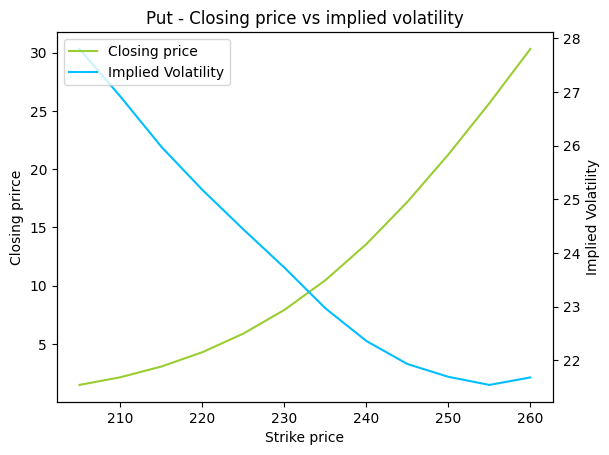

In [21]:
# Sample data
x = puts['STRIKE_PRC']
y1 = puts['CF_CLOSE']
y2 = puts['IMP_VOLT']     

# Create the figure and primary axes
fig, ax1 = plt.subplots()

# Plot data on the primary (left) y-axis
ax1.plot(x, y1, 'yellowgreen', label='Closing price')
ax1.set_xlabel('Strike price')
ax1.set_ylabel('Closing prirce', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis using twinx()
ax2 = ax1.twinx()

# Plot data on the secondary (right) y-axis
ax2.plot(x, y2, 'deepskyblue', label='Implied Volatility')
ax2.set_ylabel('Implied Volatility', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a legend (combining legends from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Put - Closing price vs implied volatility')
plt.show()

In [22]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 99 to 121
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Instrument  12 non-null     string        
 1   PUTCALLIND  12 non-null     string        
 2   STRIKE_PRC  12 non-null     Float64       
 3   EXPIR_DATE  12 non-null     datetime64[ns]
 4   CF_CLOSE    12 non-null     Float64       
 5   IMP_VOLT    12 non-null     Float64       
dtypes: Float64(3), datetime64[ns](1), string(2)
memory usage: 708.0 bytes


In [23]:
calls

,Instrument,PUTCALLIND,STRIKE_PRC,EXPIR_DATE,CF_CLOSE,IMP_VOLT
99,/AAPL2050F6.EX,CALL,205.0,2026-06-19,26.94,27.7831
101,/AAPL2100F6.EX,CALL,210.0,2026-06-19,22.63,26.9812
103,/AAPL2150F6.EX,CALL,215.0,2026-06-19,18.55,25.9915
105,/AAPL2200F6.EX,CALL,220.0,2026-06-19,14.78,25.1657
107,/AAPL2250F6.EX,CALL,225.0,2026-06-19,11.39,24.4544
109,/AAPL2300F6.EX,CALL,230.0,2026-06-19,8.42,23.7537
111,/AAPL2350F6.EX,CALL,235.0,2026-06-19,5.96,22.9761
113,/AAPL2400F6.EX,CALL,240.0,2026-06-19,4.04,22.3595
115,/AAPL2450F6.EX,CALL,245.0,2026-06-19,2.64,21.9632
117,/AAPL2500F6.EX,CALL,250.0,2026-06-19,1.66,21.6925


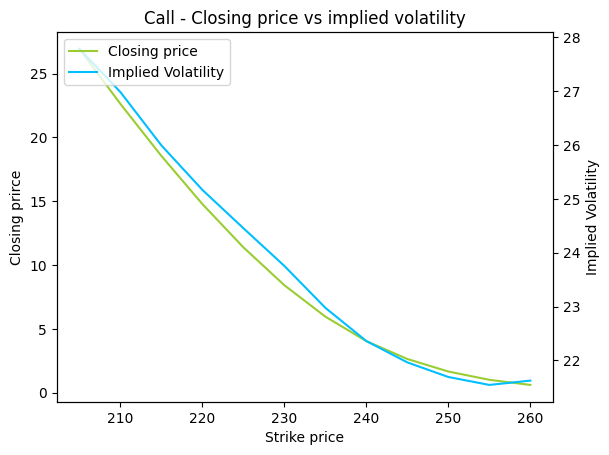

In [24]:
# Sample data
x = calls['STRIKE_PRC']
y1 = calls['CF_CLOSE']
y2 = calls['IMP_VOLT']     

# Create the figure and primary axes
fig, ax1 = plt.subplots()

# Plot data on the primary (left) y-axis
ax1.plot(x, y1, 'yellowgreen', label='Closing price')
ax1.set_xlabel('Strike price')
ax1.set_ylabel('Closing prirce', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis using twinx()
ax2 = ax1.twinx()

# Plot data on the secondary (right) y-axis
ax2.plot(x, y2, 'deepskyblue', label='Implied Volatility')
ax2.set_ylabel('Implied Volatility', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a legend (combining legends from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Call - Closing price vs implied volatility')
plt.show()

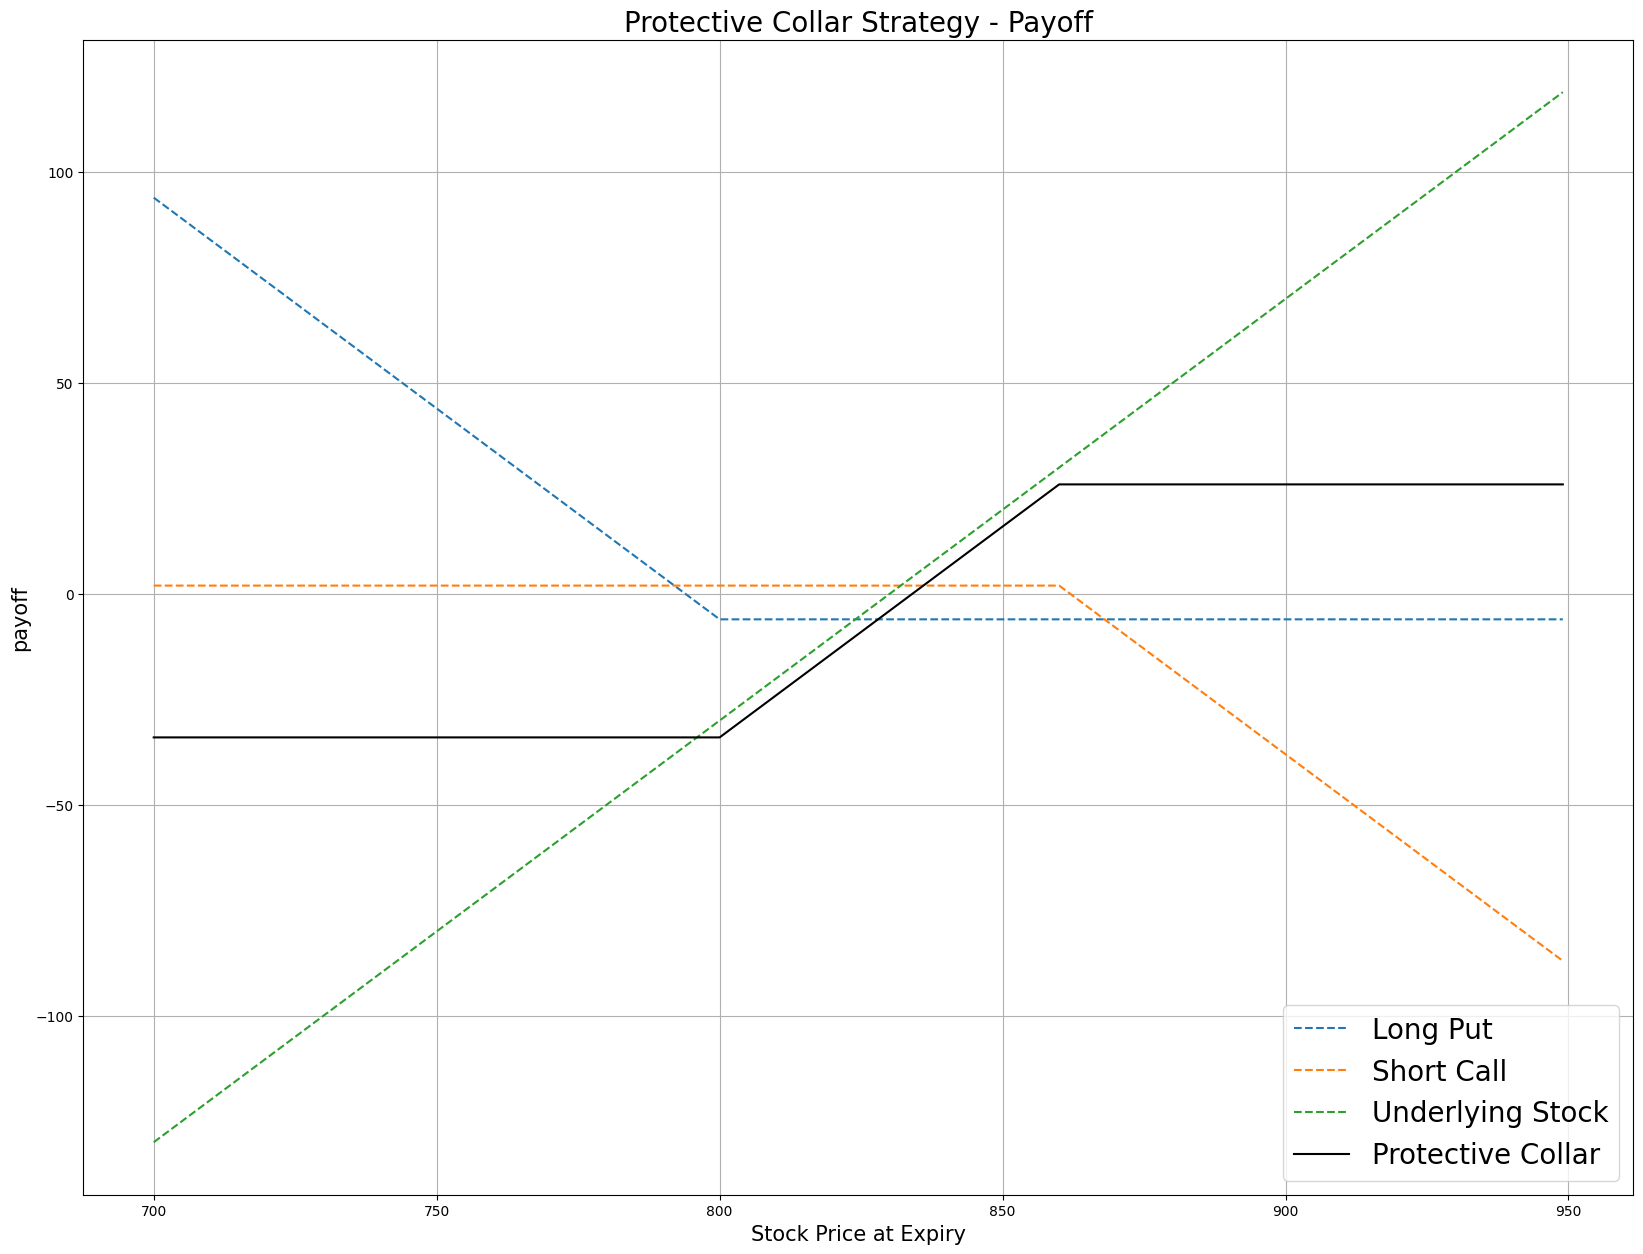

In [25]:
# https://www.quantconnect.com/learning/articles/applied-options/protective-collar
# Protective Collar
price = np.arange(700,950,1)
# assume at time 0, the price of the undelying stock is 830
k_otm_put = 800 # the strike price of OTM put
k_otm_call = 860 # the strike price of OTM call
premium_otm_put = 6 # the premium of OTM put
premium_otm_call = 2 # the premium of OTM call
# payoff for the long put position
payoff_long_put = [max(-premium_otm_put, k_otm_put-i-premium_otm_put) for i in price]
# payoff for the short call position
payoff_short_call = [min(premium_otm_call, -(i-k_otm_call-premium_otm_call)) for i in price]
# payoff for the underlying stock
payoff_stock = price - 830
# payoff for the Protective Collar Strategy
payoff = np.sum([payoff_long_put,payoff_short_call,payoff_stock], axis=0)
plt.figure(figsize=(20,15))
plt.plot(price, payoff_long_put, label = 'Long Put',linestyle='--')
plt.plot(price, payoff_short_call, label = 'Short Call',linestyle='--')
plt.plot(price, payoff_stock, label = 'Underlying Stock',linestyle='--')
plt.plot(price, payoff, label = 'Protective Collar',c='black')
plt.legend(fontsize = 20)
plt.xlabel('Stock Price at Expiry',fontsize = 15)
plt.ylabel('payoff',fontsize = 15)
plt.title('Protective Collar Strategy - Payoff',fontsize = 20)
plt.grid(True)

In [ ]:
Apple es 172.56

Compro un Put X 162 vale -2.17
Vender un Call X 180 vale +2.59

Ganando 42 centavos con las opciones


In [ ]:
Si el precio se va 185 
Gano 180 - 172.56 + 42 centavos 

In [ ]:
Si el precio se va a 150
Pierdo 172.56 - 162 + 42 centavos